# Week 1: System exploration (Group)

In the first stage, your aim is to **understand the behaviour of a system**.

You should focus on questions like:
- How do the observed signals change over time?
- How do different input patterns affect the observations?
- Are some signals more informative than others?
- What is easy to observe, and what seems hidden?

At this stage, the priority is **exploration and intuition-building**, not solving the whole project.

## Group tasks for Week 1

As a group, extend the basic experiment and **build a shared code workflow.**

Your group should aim to produce:
- a clean way to explore dataset, either from simulation or experiment,
- standard plotting functions,
- a simulation platform for studying and comparing effects of different input patterns and system dynamics (transition matrices), for example:
    - random inputs,
    - pulses,
    - oscillatory inputs,
    - activating only one input channel at a time,
    - activating different channels with different amplitudes,
    - exploring the relationship between input structure and system dynamics (such as coupling between inputs and transition matrices);
- brief documentation so that all group members can build on the same starting point.

All of the above tasks should be completed by Friday 22 May, before the scheduled check-in session.

## Week 1 deliverable

**Deliverable:** Group simulation code + brief documentation  
**Marks:** 10 group marks  
**Due:** Friday 22 May, 11am–1pm (**compulsory session**)

At the check-in session, the demonstrator will review the code and ask each member of the group questions about it. Every member of the group is therefore expected to have contributed to the code and to take full responsibility for understanding it.

## Example dataset

In [2]:
# loading dataset
import numpy as np
data = np.load("ExampleDataset.npy")
print("Dataset loaded successfully. Shape:", data.shape)  # (Trials, Timepoints, Neurons) - so we batch 
print(data[0])

Dataset loaded successfully. Shape: (5, 60, 16)
[[-8.88867782e-01  1.72964945e+00  4.62174166e-01  5.25051084e-02
  -1.24703133e+00 -2.44069048e-01  8.51658572e-01  6.85214663e-01
   4.74434757e-01 -1.12402627e+00 -1.00220481e+00 -1.15591265e-01
   1.57386773e-01 -1.00004934e+00  6.44727985e-01  1.71372949e+00]
 [-8.74849574e-01  4.88596950e-01  3.41333925e-01  6.85819165e-01
  -5.32458250e-02  4.62858498e-02 -2.93658597e-01  7.80372090e-01
  -1.56870823e+00 -1.38056224e+00  3.19860816e+00 -1.35080629e+00
  -4.30506587e-01  9.13248073e-02 -7.98868559e-01 -3.90618424e-01]
 [-1.79253620e+00  2.71420644e-01 -8.84986141e-01 -1.01873432e-01
   4.01944303e-01 -4.23869271e-01  6.03322685e-01  7.05737543e-01
  -1.11665361e+00  4.63118017e-01  5.40165063e-01 -9.15081761e-01
  -9.00265797e-01  3.00583984e-01  6.46911928e-02  1.05241150e+00]
 [ 6.26181181e-01  9.33397283e-01  5.14036317e-01 -1.43077188e+00
   1.00902262e+00  2.44314689e-01  2.26755232e-01  6.92372817e-01
  -3.27027079e-01  1.3214

## Desgin an illustrator

A class that can generate primary statistics, analyses, and visualization of any dataset. Design your illustrator in **Illustrator.py**.

To test your documentation, the demonstrator will use your illustrator here, but will never see your code (in this section). 

Please make your annotations clear and comprehensive!

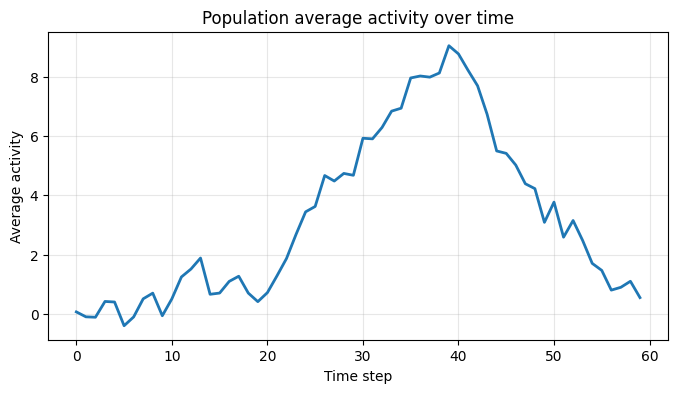

AttributeError: 'Illustrator' object has no attribute 'plot_pca_2d'

In [16]:
from Illustrator_arnav import Illustrator
import numpy as np
illustrator = Illustrator(data)
illustrator.plot_population_average()
def plot_pca_2d(self, pca_results, trial_idxs=[0]):
    """
    Plots the first two Principal Components as a 2D trajectory.
    
    Args:
        pca_results: The tuple returned by get_PCA()
        trial_idxs: List of trial indices to plot
    """
    # Extract scores from the 5th position in the tuple
    # scores shape is (Trials, Timepoints, Components)
    scores = pca_results[4] 
    
    if scores.shape[2] < 2:
        print(f"Warning: Only {scores.shape[2]} components available. Need at least 2 for a 2D plot.")
        return

    plt.figure(figsize=(8, 6))
    
    for idx in trial_idxs:
        # Extract PC1 and PC2 for this specific trial
        pc1 = scores[idx, :, 0]
        pc2 = scores[idx, :, 1]
        
        # Plot the trajectory line
        line = plt.plot(pc1, pc2, alpha=0.7, label=f'Trial {idx}')
        
        # Add a marker for the start and end of the trial
        plt.scatter(pc1[0], pc2[0], color='green', marker='o', s=50) # Start
        plt.scatter(pc1[-1], pc2[-1], color='red', marker='x', s=50)  # End

        plt.xlabel(f'PC1 ({pca_results[0][0]*100:.1f}% variance)')
        plt.ylabel(f'PC2 ({pca_results[0][1]*100:.1f}% variance)')
        plt.title('Neural State Space: PC1 vs PC2')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()
# 1. Run the PCA
pca_out = illustrator.get_PCA(threshold=0.99) # Use high threshold to ensure we get >1 component

# 2. Plot the first 2 PCs for the first 3 trials
illustrator.plot_pca_2d(pca_out, trial_idxs=[0, 1, 2])
pass


## Design a simulator

In GG4, we use a simple linear model:
$$
x_{t+1} = Ax_t + Bu_t + w_t, w_t \sim \mathcal{N}(0, Q)
$$
$$
y_t = Cx_t + o_t, o_t \sim \mathcal{N}(0, R)
$$

Your simulator should be able to simulate observation of any length given different parameters.

Design your simulator in **Simulator.py**.

To test your documentation, the demonstrator will use your simulator here, but will never see your code (in this section). 
Please make your annotations clear and comprehensive!

Combining the illustrator and simulator, what's your findings? Illustrate them.
This forms your answer to the question: "effects of different input patterns and system dynamics"

ModuleNotFoundError: No module named 'test'

In [ ]:
from Controllers import Controllers
from Simulator import Simulator
from LDSParams import LDSParams
illustrator = Illustrator(np.load("ExampleDataset.npy"))

controller_factory = Controllers()
controller = controller_factory.make_pulse(0,10,10,2)


#2 hidden state 2 input state matrices
A = np.array([[0.01,0 ],
            [0, 0.01]])
B = np.array([[0.2, 0],
            [0,0.2 ]])
C = np.array([[0.95, 0],
            [0,0.95 ]])
Q = np.array([[0.95, 0],
            [0,0.95 ]])
R = np.array([[0.95, 0],
            [0,0.95 ]])
mu_0 = np.array([0,0])
P_0 = np.array([[0.95, 0],
            [0,0.95 ]])


params = (A,B,C,Q,R,mu_0,P_0)

params = LDSParams.from_tuple(params)

sim = Simulator(params,illustrator,controller)
seed = (mu_0,P_0)
# sim.compare_plot(seed)
sim.generate_data(3,60,seed,controller)

array([[[ 2.32645616e+00, -1.91753002e+00],
        [ 2.55189652e+00,  2.01858618e+00],
        [ 1.94550324e+00,  1.29974598e-01],
        [ 2.76181880e+00,  6.80652577e-01],
        [-9.53544273e-01,  3.74792141e-01],
        [ 6.06604956e-02,  3.06554012e-01],
        [ 1.96494478e+00,  1.00773210e+00],
        [ 1.89698150e+00,  3.76581841e+00],
        [ 3.19459069e+00,  1.38382636e+00],
        [ 1.15181263e+00,  1.00734199e+00],
        [ 1.09421393e+00,  3.68363978e+00],
        [ 1.13388733e+00, -3.85059617e-01],
        [ 1.39341056e+00,  1.22296090e+00],
        [ 2.33330751e+00,  7.01531666e-02],
        [ 1.55556439e+00, -5.38072165e-01],
        [-2.38133375e+00,  2.10057664e+00],
        [ 3.79425997e-01,  1.48030120e+00],
        [-5.50255244e-01,  4.02497779e+00],
        [-2.79189366e+00, -1.15183921e+00],
        [ 1.91887912e+00,  2.62449384e-01],
        [-5.91871706e-01,  1.54735521e+00],
        [ 8.53067265e-03,  4.40972194e-02],
        [-1.03261566e+00, -1.850